# LSTM and Forecast Notebook
Load lstm_best.pth, preprocess the latest data, and forecast the next 7 days of prices.


In [24]:
# ----- Cell 1: Imports & Settings -----
import os
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TICKER  = "LULU"     

DROPOUT = 0.5        

HORIZON = 5         



Device: cuda


## 2. Load checkpoint & metadata


In [25]:
CHK_PATH = "lstm_best.pth"
chkpt    = torch.load(CHK_PATH, map_location=device)

#   'model_state', 'hidden_dim', 'num_layers', 'feature_order', 'window'
feature_cols = chkpt["feature_order"]       # was feature_order, not features
hidden_dim   = chkpt["hidden_dim"]
num_layers   = chkpt["num_layers"]
WINDOW_SIZE  = chkpt["window"]              # sliding window length
TARGET       = "Return_1D"                  # we know this from training

print("Loaded checkpoint with:")
print(f" • {len(feature_cols)} features: {feature_cols}")
print(f" • hidden_dim = {hidden_dim}")
print(f" • num_layers = {num_layers}")
print(f" • window_size = {WINDOW_SIZE}")


Loaded checkpoint with:
 • 15 features: ['lag1_ret', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return_3D', 'Volatility_3D', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']
 • hidden_dim = 100
 • num_layers = 2
 • window_size = 30


## 3. Define & load the LSTM model


In [26]:


# 1) Reload your cached history CSV for LULU
df = pd.read_csv("data/LULU_full_history.csv", parse_dates=["date"])
df = (
    df.rename(columns={
        "open":"Open", "high":"High", "low":"Low",
        "close":"Close", "volume":"Volume"
    })
    .set_index("date")
)

# 2) Recompute the identical indicators + lag1_ret
def compute_indicators(df):
    delta = df["Close"].diff()
    gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
    ru = gain.ewm(span=14).mean(); rd = loss.ewm(span=14).mean()
    rs = ru/rd
    df["RSI"] = 100 - 100/(1+rs)

    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    macd = ema12 - ema26
    df["MACD"]        = macd
    df["MACD_Signal"] = macd.ewm(span=9).mean()
    df["MACD_Hist"]   = df["MACD"] - df["MACD_Signal"]

    sma20 = df["Close"].rolling(20).mean()
    std20 = df["Close"].rolling(20).std()
    df["BB_Mid"], df["BB_Upper"], df["BB_Lower"] = sma20, sma20+2*std20, sma20-2*std20

    df["Return_1D"] = df["Close"].pct_change().shift(-1)
    df["lag1_ret"]  = df["Return_1D"].shift(1)
    return df.dropna()

df = compute_indicators(df)

# 3) Rebuild the quarterly-scalers & scaled DataFrame
def prepare_quarterly(df, feats, tgt, window):
    df2 = df.copy()
    df2["Quarter"] = df2.index.to_period("Q")
    scalers, chunks = {}, []
    for q, g in df2.groupby("Quarter"):
        if len(g) < window: 
            continue
        m = MinMaxScaler()
        arr = m.fit_transform(g[feats + [tgt]].values)
        chunks.append(pd.DataFrame(arr, index=g.index, columns=feats+[tgt]))
        scalers[str(q)] = m
    df_s = pd.concat(chunks).sort_index().dropna()
    return scalers, df_s

scalers_q, df_scaled = prepare_quarterly(df, feature_cols, TARGET, WINDOW_SIZE)
print("Available quarters (last 3):", list(scalers_q.keys())[-3:])


Available quarters (last 3): ['2024Q4', '2025Q1', '2025Q2']


## 4. Reload & preprocess the latest data


In [27]:


def build_all_windows(df_s, feats, tgt, window):
    X = []
    data = df_s[feats].values
    for i in range(window, len(df_s)):
        X.append(data[i-window:i])
    return np.array(X)

X_all = build_all_windows(df_scaled, feature_cols, TARGET, WINDOW_SIZE)
last_window = X_all[-1]
print("Last window shape:", last_window.shape)  # (WINDOW_SIZE, n_features)


Last window shape: (30, 15)


## 6. Forecast future returns


In [28]:

import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            dropout=dropout, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        h0 = torch.zeros(self.lstm.num_layers, x.size(0),
                         self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :]).squeeze(-1)

# Instantiate & load your weights
model = LSTMModel(
    input_dim  = len(feature_cols),
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    dropout    = DROPOUT
).to(device)

model.load_state_dict(chkpt["model_state"])
model.eval()
print(model)


LSTMModel(
  (lstm): LSTM(15, 100, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


## 7. Convert scaled returns → raw returns & prices


In [29]:

import torch

def forecast_future_scaled(net, window_scaled, horizon):
    arr, preds = window_scaled.copy(), []
    for _ in range(horizon):
        inp = torch.tensor(arr).float().unsqueeze(0).to(device)
        with torch.no_grad():
            p = net(inp).item()
        preds.append(p)
        # roll the window
        new_row = arr[-1].copy()
        new_row[-1] = p
        arr = np.vstack([arr[1:], new_row])
    return np.array(preds)

fc_scaled = forecast_future_scaled(model, last_window, HORIZON)
print(f"Scaled returns forecast (next {HORIZON} days):\n", np.round(fc_scaled,4))


Scaled returns forecast (next 5 days):
 [0.7297 0.4492 0.5433 0.5763 0.4571]


## 8. Plot the forecasts


In [30]:

q_last = str(df_scaled.index[-1].to_period("Q"))
m = scalers_q[q_last]

minv, maxv = m.data_min_[-1], m.data_max_[-1]
raw_rets = fc_scaled * (maxv - minv) + minv
pct_rets = raw_rets * 100

# Convert returns → prices
last_price = df["Close"].iloc[-1]
price_forecast = [last_price * (1 + raw_rets[0])]
for r in raw_rets[1:]:
    price_forecast.append(price_forecast[-1] * (1 + r))

print(f"{HORIZON}-day returns (%):", np.round(pct_rets,4))
print(f"{HORIZON}-day price forecast:", np.round(price_forecast,4))


5-day returns (%): [ 5.1394 -0.5206  1.3791  2.0446 -0.3609]
5-day price forecast: [339.5477 337.78   342.4383 349.4397 348.1786]


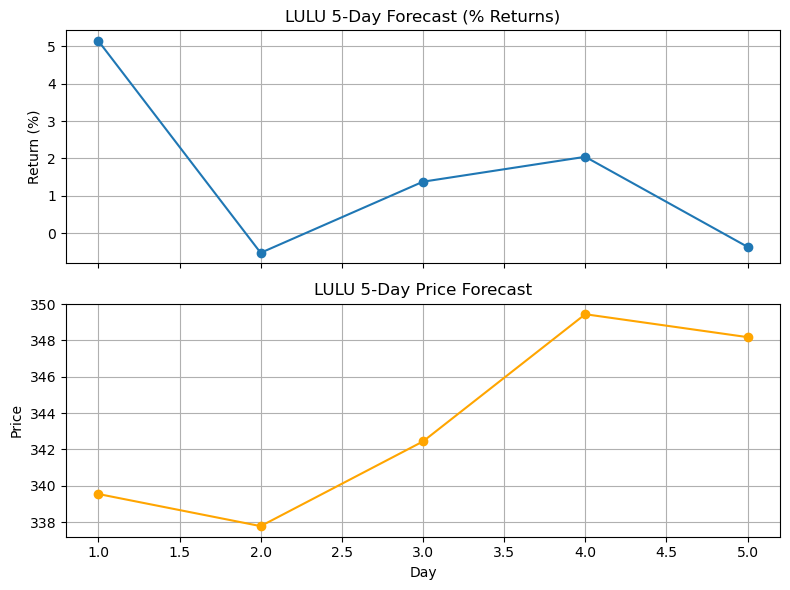

In [31]:
days = np.arange(1, HORIZON+1)

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)

# % returns
ax1.plot(days, pct_rets, marker='o')
ax1.set_ylabel("Return (%)")
ax1.set_title(f"{TICKER} {HORIZON}-Day Forecast (% Returns)")
ax1.grid(True)

# Price
ax2.plot(days, price_forecast, marker='o', color='orange')
ax2.set_ylabel("Price")
ax2.set_title(f"{TICKER} {HORIZON}-Day Price Forecast")
ax2.set_xlabel("Day")
ax2.grid(True)

plt.tight_layout()
plt.show()
